# Internet Usage Analysis using K-Means Clustering

# Problem Statement

The objective of this project is to analyze internet usage trends from 2000 to 2022 using K-Means Clustering and identify groups with similar usage patterns.

# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv('internet_usage.csv')
df.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,..,0.00472257,0.0045614,0.0878913,0.105809,1.22415,2.10712,1.9,...,7,8.26,11,13.5,16.8,17.6,18.4,..,..,..
1,Albania,ALB,0.114097,0.325798,0.390081,0.9719,2.42039,6.04389,9.60999,15.0361,...,54.3,56.9,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137,83.1356
2,Algeria,DZA,0.491706,0.646114,1.59164,2.19536,4.63448,5.84394,7.37598,9.45119,...,29.5,38.2,42.9455,47.6911,49.0385,58.9776,60.6534,66.2356,71.2432,..
3,American Samoa,ASM,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Andorra,AND,10.5388,..,11.2605,13.5464,26.838,37.6058,48.9368,70.87,...,86.1,87.9,89.7,91.5675,..,90.7187,93.2056,93.8975,94.4855,..


# Data Understanding

In [3]:
print("Number of rows :",df.shape[0])
print("Number of columns :",df.shape[1])

Number of rows : 217
Number of columns : 26


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  217 non-null    object
 1   Country Code  217 non-null    object
 2   2000          217 non-null    object
 3   2001          217 non-null    object
 4   2002          217 non-null    object
 5   2003          217 non-null    object
 6   2004          217 non-null    object
 7   2005          217 non-null    object
 8   2006          217 non-null    object
 9   2007          217 non-null    object
 10  2008          217 non-null    object
 11  2009          217 non-null    object
 12  2010          217 non-null    object
 13  2011          217 non-null    object
 14  2012          217 non-null    object
 15  2013          217 non-null    object
 16  2014          217 non-null    object
 17  2015          217 non-null    object
 18  2016          217 non-null    object
 19  2017    

In [5]:
df.describe()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,217,217,217,217,217,217,217,217,217,217,...,217,217,217,217,217,217,217,217,217,217
unique,217,217,197,200,202,196,198,199,199,197,...,194,196,199,203,175,183,191,185,178,58
top,Afghanistan,AFG,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
freq,1,1,21,18,15,21,18,17,18,13,...,16,17,14,11,41,31,25,27,34,158


In [6]:
df.describe(include=object)

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,217,217,217,217,217,217,217,217,217,217,...,217,217,217,217,217,217,217,217,217,217
unique,217,217,197,200,202,196,198,199,199,197,...,194,196,199,203,175,183,191,185,178,58
top,Afghanistan,AFG,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
freq,1,1,21,18,15,21,18,17,18,13,...,16,17,14,11,41,31,25,27,34,158


In [7]:
df.columns

Index(['Country Name', 'Country Code', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')

In [8]:
df.isnull().sum()

Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
2023            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["2000"].unique()

array(['..', '0.114097', '0.491706', '10.5388', '0.105046', '6.48223',
       '7.03868', '1.30047', '15.4428', '46.7561', '33.7301', '0.147758',
       '8', '6.15373', '0.0710394', '3.97368', '1.8604', '29.4317',
       '5.96384', '0.225248', '42.9499', '0.400944', '1.44276', '1.08296',
       '2.90267', '2.87069', '8.99628', '5.37092', '0.0770802',
       '0.0772484', '1.82244', '0.0470226', '0.25212', '51.3',
       '0.0533942', '0.0357071', '16.6', '1.77591', '2.20753', '0.271741',
       '0.00590211', '0.0263547', '5.80025', '0.231462', '6.64488',
       '0.541183', '15.2554', '9.78053', '39.1724', '0.194501', '8.81484',
       '3.70469', '1.46219', '0.641265', '1.1774', '0.132355', '0.136712',
       '28.577', '0.926192', '0.0152638', '32.9164', '1.49685', '37.2485',
       '14.3079', '6.35706', '1.21614', '0.921795', '0.484746', '30.2163',
       '0.153615', '19.1316', '9.13884', '31.7478', '4.06391', '16.1131',
       '0.712333', '0.0954249', '0.230103', '0.6', '0.231271', '1.20

In [11]:
df["2001"].unique()

array(['0.00472257', '0.325798', '0.646114', '..', '0.136014', '8.89929',
       '9.78081', '1.63109', '17.1', '52.6893', '39.1855', '0.305565',
       '11.8', '15.0386', '0.129808', '11.9365', '4.30062', '31.2884',
       '0.363418', '47.5097', '0.864629', '2.12046', '1.20053', '3.43089',
       '4.52849', '12.9178', '7.6123', '0.157732', '0.106001', '2.68533',
       '0.0769561', '0.277051', '60.2', '0.0785434', '0.0459341', '19.1',
       '2.63965', '2.8542', '0.443068', '0.0114758', '0.0322236',
       '9.55948', '0.395748', '11.5586', '1.07975', '18.8188', '14.6972',
       '42.9575', '0.343526', '13.2452', '4.42939', '2.67044', '0.838946',
       '1.5', '0.16526', '0.157815', '31.5275', '1.28159', '0.0371624',
       '43.247', '1.85798', '43.1054', '26.3259', '6.25159', '1.34762',
       '1.33679', '0.992344', '31.6509', '0.200008', '21.1711', '10.935',
       '35.4641', '5.1281', '25.3802', '1.7382', '0.175542', '0.299569',
       '1', '0.340832', '1.41528', '38.6714', '14.5286'

# Data Cleaning & Preprocessing

In [12]:
df = df.replace("..",np.nan)

In [13]:
df.isna().sum()/len(df)*100

Country Name     0.000000
Country Code     0.000000
2000             9.677419
2001             8.294931
2002             6.912442
2003             9.677419
2004             8.294931
2005             7.834101
2006             8.294931
2007             5.990783
2008             6.912442
2009             6.912442
2010             7.373272
2011             5.990783
2012             6.912442
2013             7.373272
2014             7.373272
2015             7.834101
2016             6.451613
2017             5.069124
2018            18.894009
2019            14.285714
2020            11.520737
2021            12.442396
2022            15.668203
2023            72.811060
dtype: float64

In [14]:
# We dropped the column because it contained more than 50% missing values, which could negatively affect the model performance and data quality.
df.drop(columns="2023",inplace=True)
df.columns

Index(['Country Name', 'Country Code', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022'],
      dtype='object')

In [15]:
for i in df.columns[2:] :
    df[i] = pd.to_numeric(df[i])
    df[i].fillna(df[i].mean(),inplace=True)
df.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,AFG,8.732304,0.004723,0.004561,0.087891,0.105809,1.22415,2.107120,1.900000,...,5.900000,7.000000,8.260000,11.000000,13.500000,16.800000,17.600000,18.40000,67.88072,71.291703
1,Albania,ALB,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.609990,15.036100,...,51.800000,54.300000,56.900000,59.600000,62.400000,65.400000,68.550400,72.23770,79.32370,82.613700
2,Algeria,DZA,0.491706,0.646114,1.591640,2.195360,4.634480,5.84394,7.375980,9.451190,...,22.500000,29.500000,38.200000,42.945500,47.691100,49.038500,58.977600,60.65340,66.23560,71.243200
3,American Samoa,ASM,8.732304,10.653857,13.617630,16.108085,18.520151,20.79910,23.379992,25.597037,...,42.138295,45.211018,48.034621,51.389652,54.664937,57.863789,61.250281,64.49232,67.88072,71.291703
4,Andorra,AND,10.538800,10.653857,11.260500,13.546400,26.838000,37.60580,48.936800,70.870000,...,84.400000,86.100000,87.900000,89.700000,91.567500,57.863789,90.718700,93.20560,93.89750,94.485500


In [16]:
df.isna().sum()

Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
dtype: int64

In [17]:
df["Country Code"].unique()

array(['AFG', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'ATG', 'ARG', 'ARM',
       'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB', 'BLR',
       'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BIH', 'BWA', 'BRA',
       'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'CPV', 'KHM', 'CMR', 'CAN',
       'CYM', 'CAF', 'TCD', 'CHI', 'CHL', 'CHN', 'COL', 'COM', 'COD',
       'COG', 'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE', 'DNK',
       'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST',
       'SWZ', 'ETH', 'FRO', 'FJI', 'FIN', 'FRA', 'PYF', 'GAB', 'GMB',
       'GEO', 'DEU', 'GHA', 'GIB', 'GRC', 'GRL', 'GRD', 'GUM', 'GTM',
       'GIN', 'GNB', 'GUY', 'HTI', 'HND', 'HKG', 'HUN', 'ISL', 'IND',
       'IDN', 'IRN', 'IRQ', 'IRL', 'IMN', 'ISR', 'ITA', 'JAM', 'JPN',
       'JOR', 'KAZ', 'KEN', 'KIR', 'PRK', 'KOR', 'XKX', 'KWT', 'KGZ',
       'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LIE', 'LTU', 'LUX',
       'MAC', 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MRT',
       'MUS', 'MEX',

In [18]:
df["Country Name"].nunique()

217

# Exploratory Data Analysis (EDA)

<Axes: >

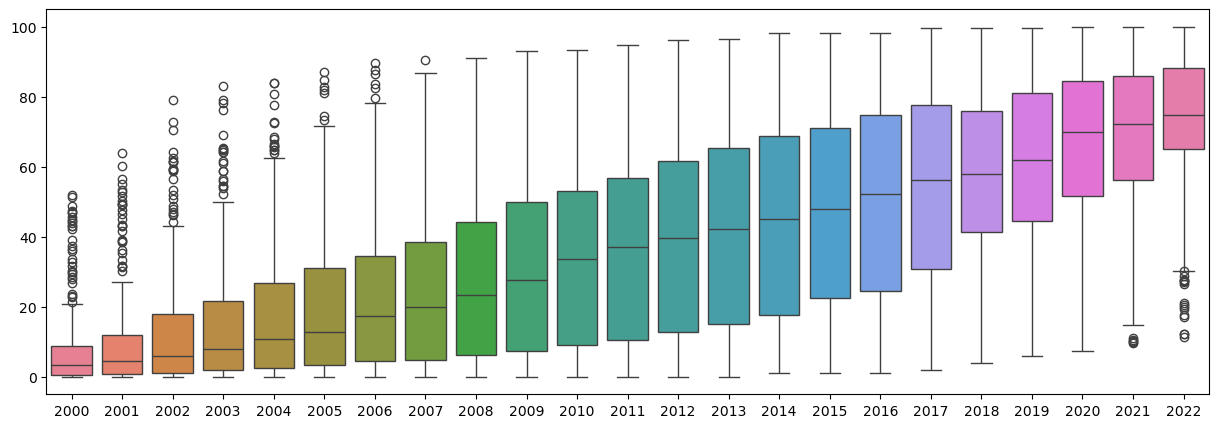

In [19]:
plt.figure(figsize=(15,5))
sns.boxplot(df)

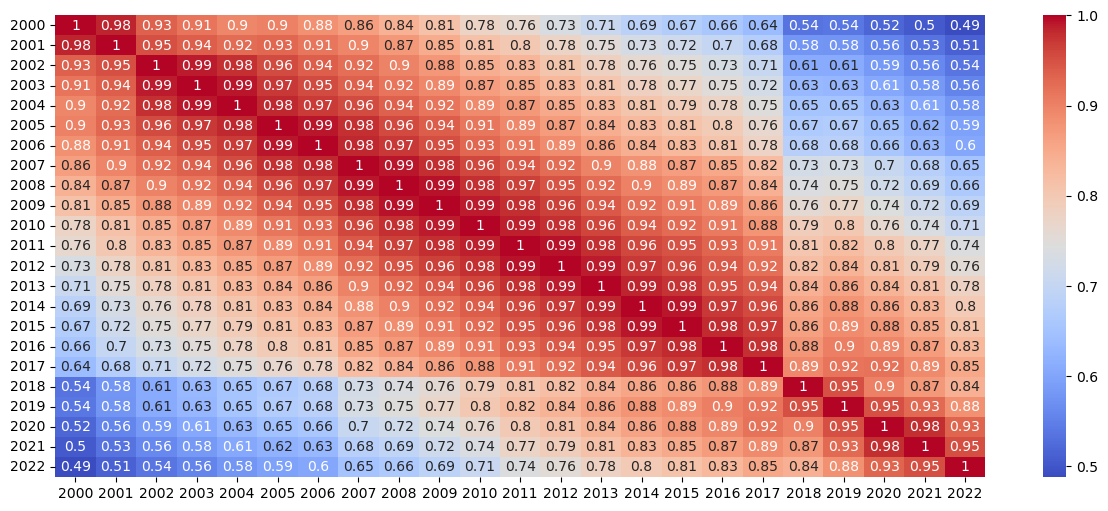

In [20]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Encoding Categorical Features

In [21]:
# Categorical columns with 217 unique values were dropped to reduce complexity and avoid high-dimensional encoding.
# Remove unnecessary features
df.drop(columns=["Country Name","Country Code"],inplace=True)

# Feature Scaling

In [22]:
sc = StandardScaler()
scaled_data = sc.fit_transform(df)
scaled_data

array([[ 0.00000000e+00, -7.20216349e-01, -7.70620589e-01, ...,
        -1.87514788e+00,  0.00000000e+00,  0.00000000e+00],
       [-6.82467752e-01, -6.98501553e-01, -7.48796757e-01, ...,
         3.15100936e-01,  4.80910061e-01,  5.09080974e-01],
       [-6.52565250e-01, -6.76838119e-01, -6.80777848e-01, ...,
        -1.56176615e-01, -6.91388960e-02, -2.18089591e-03],
       ...,
       [-6.84969857e-01, -7.14394639e-01, -7.41510345e-01, ...,
        -2.06166872e+00, -2.22710215e+00, -2.40992507e+00],
       [-6.76372174e-01, -7.04768824e-01, -7.43833856e-01, ...,
        -1.62701756e+00, -1.72015992e+00, -1.80114103e+00],
       [-6.59713805e-01, -6.66441002e-01, -7.08609038e-01, ...,
        -1.43176628e+00, -1.48854687e+00, -1.74146046e+00]])

# Find Optimal Number of Clusters (Elbow Method)

In [23]:
wcss = []
for i in range(2,11) :
    km = KMeans(n_clusters=i)
    km.fit_predict(scaled_data)
    wcss.append(km.inertia_)

wcss

[2099.881698548921,
 1135.2250653578283,
 792.9089713753433,
 642.7594474076518,
 598.045610608511,
 538.9972427008922,
 489.26946604205995,
 487.89910083627524,
 437.2836716315756]

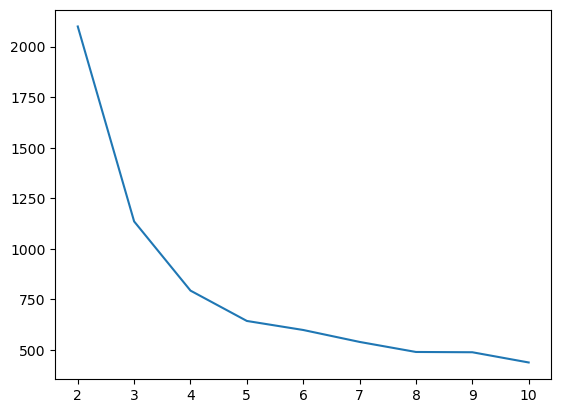

In [24]:
plt.plot(range(2,11),wcss)
plt.show()

# Train K-Means Clustering Model

In [25]:
km = KMeans(n_clusters=2,random_state=0)
km.fit_predict(scaled_data)

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [26]:
km.labels_

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [27]:
km.inertia_

2099.881698548921

# Assign Data Points to Clusters

In [28]:
df["cluster"] = km.labels_
df["cluster"]

0      0
1      0
2      0
3      0
4      1
      ..
212    0
213    0
214    0
215    0
216    0
Name: cluster, Length: 217, dtype: int32

# Cluster Visualization

In [29]:
df.groupby('cluster').mean()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.349646,2.746592,3.896729,5.090751,6.218251,7.519514,9.208679,10.036972,12.294286,14.523694,...,24.069130,27.445104,30.723187,34.345207,38.368990,44.986125,48.255048,52.109636,56.365839,60.844093
1,19.448867,23.930252,29.939145,34.606326,39.175195,43.095688,47.173800,51.722577,55.745291,59.301532,...,72.476647,75.040208,77.100733,80.007485,82.026034,79.485545,83.069439,85.282999,87.214349,88.833370


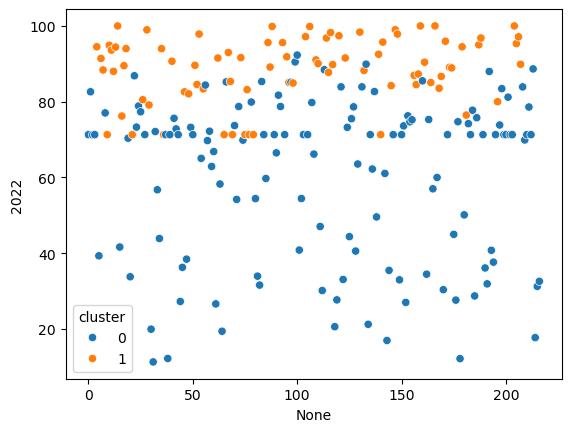

In [30]:
sns.scatterplot(x=df.index, y=df["2022"], hue=df["cluster"])

plt.show()

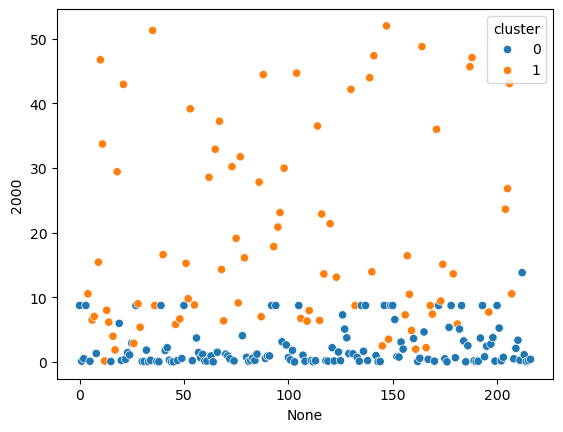

In [31]:
sns.scatterplot(x=df.index, y=df["2000"], hue=df["cluster"])

plt.show()

# Cluster Evaluation

In [32]:
score = silhouette_score(scaled_data, df["cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.47775457838031343


# Insights & Conclusion
- Internet usage increased steadily from 2000 to 2022
- K-Means grouped similar usage patterns
- Clusters show different growth trends